In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.- Analisis exploratorio

In [2]:
df = pd.read_csv('../data/Mall_Customers.csv', index_col='CustomerID')


In [3]:
df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [4]:
df.shape


(200, 4)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [6]:
df.describe()


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [7]:
df.isna().sum()


Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df.isin([np.inf, -np.inf]).sum()


Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.value_counts('Gender')


Gender
Female    112
Male       88
Name: count, dtype: int64

### A.- Analisis univariado

In [10]:
df_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


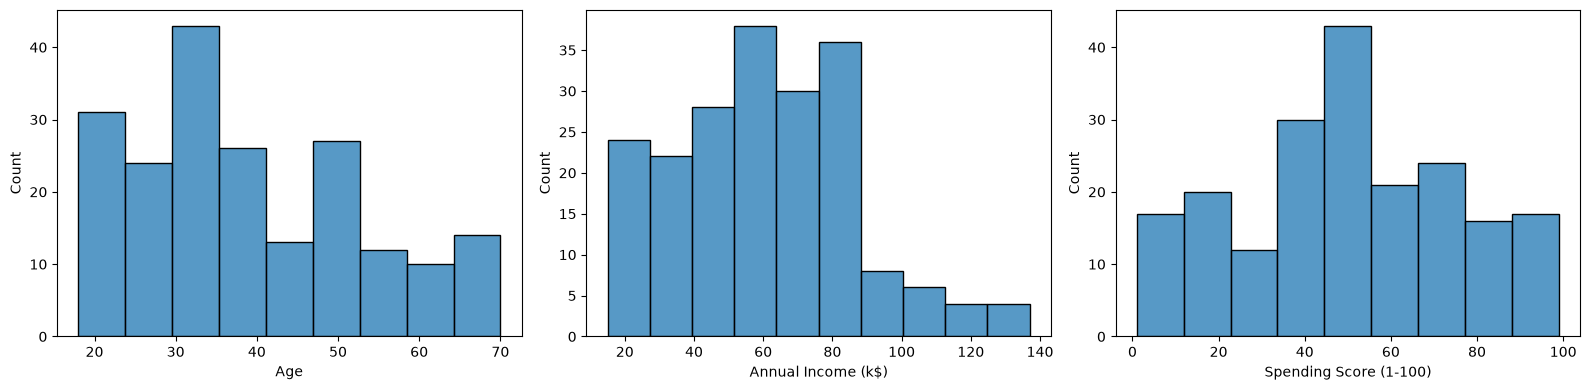

In [11]:
plt.figure(figsize=(16, 4))

for i, name in enumerate(df_num, start=1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x=name)
    plt.tight_layout()


<Axes: xlabel='Gender', ylabel='count'>

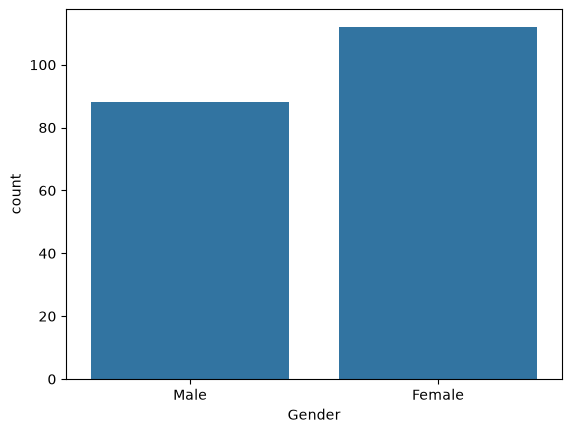

In [12]:
sns.countplot(data=df, x='Gender')


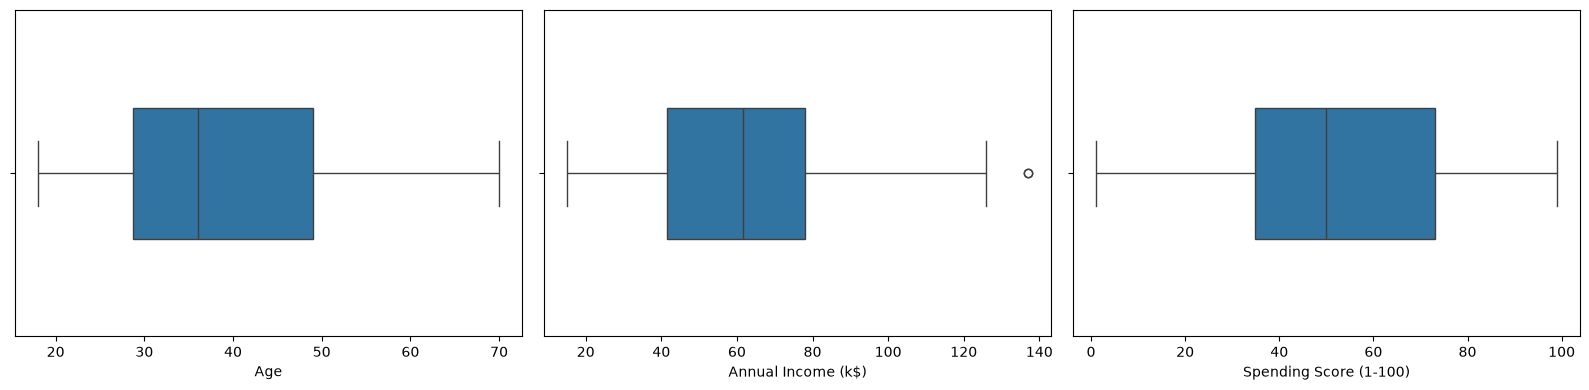

In [13]:
plt.figure(figsize=(16, 4))

for i, name in enumerate(df_num, start=1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x=name, width=0.4)
    plt.tight_layout()


### B.- Analisis bivariado

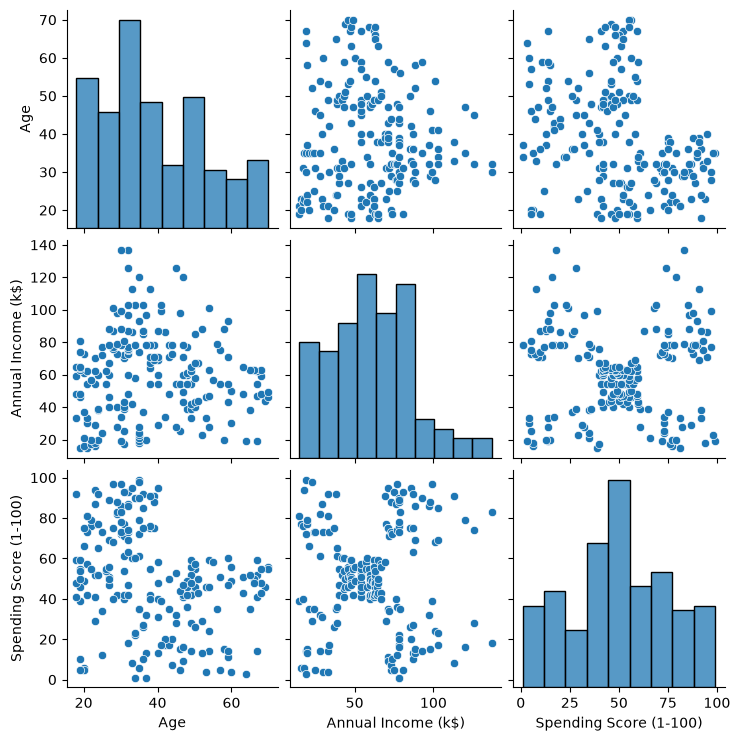

In [14]:
sns.pairplot(data=df)


<Axes: >

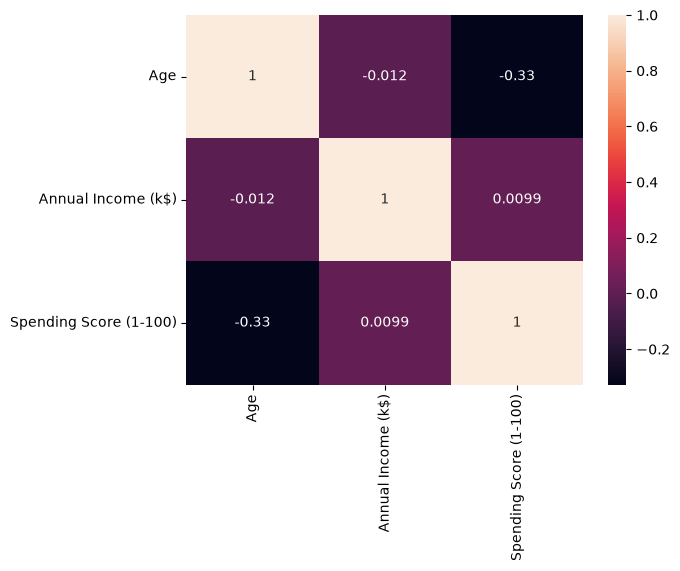

In [15]:
df_num = df.drop('Gender', axis=1)
sns.heatmap(data=df_num.corr(), annot=True)


### Conclusiones

* Nuestro dataset parece un poco pequenio
* No parace haber casi ningun valor extremo
* En annual income y spending score se nota bastante los clusters
* No parece haber valores correlacionados


### Preprocesamiento recomendado

1. **Codificar** — `Gender` con `LabelEncoder`.
2. **Estandarizar** — `Annual Income` y `Spending Score` tienen escalas distintas.
3. **Seleccionar features** — probar combinaciones de Age, Income, Score.